In [1]:
# Display tools
from IPython.display import HTML, display  # For HTML rendering in notebooks
import os 
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import tensorflow as tf

In [3]:
import matplotlib.pyplot as plt

def plot_score(hist):
    fig, ax = plt.subplots(5, 1, figsize=(10, 20))  # Corrected 'subplot' to 'subplots'
    ax = ax.ravel()

    for i, met in enumerate(['accuracy', 'precision', 'recall', 'AUC', 'loss']):
        ax[i].plot(hist.history[met])
        ax[i].plot(hist.history['val_' + met])
        ax[i].set_title(f'Model {met}')
        ax[i].set_xlabel('Epochs')
        ax[i].set_ylabel(met)
        ax[i].legend(['Train', 'Validation'])

    plt.tight_layout()
    plt.show()


In [4]:
import os
import numpy as np

# Set directory where .npy files are stored
npy_dir = 'npy_data'

# Load preprocessed datasets
train_X_rgb = np.load(os.path.join(npy_dir, 'train_X_rgb.npy'))
train_Y     = np.load(os.path.join(npy_dir, 'train_Y.npy'))
test_X_rgb  = np.load(os.path.join(npy_dir, 'test_X_rgb.npy'))
test_Y      = np.load(os.path.join(npy_dir, 'test_Y.npy'))

In [5]:
# If not already defined earlier, calculate class weights again:
import pandas as pd

labels = pd.read_csv(r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_labels.csv")
count_normal = (labels['Target'] == 0).sum()
count_pneumonia = (labels['Target'] == 1).sum()
train_count = len(train_X_rgb)

classweight = {
    0: (1 / count_normal) * (train_count / 2.0),
    1: (1 / count_pneumonia) * (train_count / 2.0)
}

In [6]:
from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras import Model


In [7]:
METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='AUC'),
    tf.keras.metrics.TruePositives(name='tp'),
    tf.keras.metrics.TrueNegatives(name='tn'),
    tf.keras.metrics.FalsePositives(name='fp'),
    tf.keras.metrics.FalseNegatives(name='fn'),
    tf.keras.metrics.SpecificityAtSensitivity(0.9, name='specificity_at_sens_90'),
    tf.keras.metrics.SensitivityAtSpecificity(0.9, name='sensitivity_at_spec_90'),
]

In [8]:
import tensorflow as tf

# Flexible Exponential Decay Function
def get_exponential_decay_fn(lr_initial=0.01, decay_steps=20, decay_rate=0.1):
    """
    Returns a learning rate function using exponential decay.
    """
    return lambda epoch: lr_initial * decay_rate ** (epoch / decay_steps)

# Returns a LearningRateScheduler callback with decay configuration
def get_lr_scheduler_cb(lr_initial=0.01, decay_steps=20, decay_rate=0.1):
    return tf.keras.callbacks.LearningRateScheduler(
        schedule=get_exponential_decay_fn(lr_initial, decay_steps, decay_rate),
        verbose=1
    )

# Returns a ModelCheckpoint callback that saves to a unique file
def get_model_checkpoint_cb(model_name):
    return tf.keras.callbacks.ModelCheckpoint(
        filepath=f"{model_name}.h5",
        save_best_only=True,
        monitor="val_loss",
        mode="min",
        verbose=1
    )

# Shared EarlyStopping callback
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor="val_loss",
    mode="min",
    verbose=1
)

Baseline Model CNN

In [9]:
def build_fcnn_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(64, 64, 3)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

In [10]:
model_fcnn=build_fcnn_model()


c:\Users\samya\PyCharmProject\Pneumonia-Detection\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
fcnn_summary=model_fcnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,573,633 (6.00 MB)

 Trainable params: 1,573,377 (6.00 MB)

 Non-trainable params: 256 (1.00 KB)

In [12]:
model_fcnn.compile(optimizer='adam',loss='binary_crossentropy',metrics=METRICS)

In [13]:
checkpoint_cb = get_model_checkpoint_cb("fcnn_model")
lr_scheduler_cb = get_lr_scheduler_cb()

In [14]:
callbacks = [checkpoint_cb, early_stopping_cb, lr_scheduler_cb]
history_fcnn = model_fcnn.fit(
    train_X_rgb,
    train_Y,
    epochs=100,
    batch_size=128,
    validation_split=0.15,
    class_weight=classweight,
    verbose=1,
    callbacks=callbacks
)


Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/100
177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - AUC: 0.8871 - accuracy: 0.7819 - fn: 625.8813 - fp: 1586.8870 - loss: 0.4217 - precision: 0.7570 - recall: 0.8774 - sensitivity_at_spec_90: 0.7325 - specificity_at_sens_90: 0.6203 - tn: 3639.6216 - tp: 5539.6104
Epoch 1: val_loss improved from inf to 0.30169, saving model to fcnn_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - AUC: 0.8876 - accuracy: 0.7824 - fn: 630.7989 - fp: 1599.9386 - loss: 0.4206 - precision: 0.7575 - recall: 0.8778 - sensitivity_at_spec_90: 0.7335 - specificity_at_sens_90: 0.6220 - tn: 3684.0503 - tp: 5603.3462 - val_AUC: 0.9668 - val_accuracy: 0.8678 - val_fn: 77.0000 - val_fp: 452.0000 - val_loss: 0.3017 - val_precision: 0.8245 - val_recall: 0.9650 - val_sensitivity_at_spec_90: 0.9137 - val_specificity_at_sens_90: 0.9168 - val_tn: 1350.0000 - val_tp: 2124.0000 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.008912509381337455.
Epoch 2/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - AUC: 0.9597 - accuracy: 0.8834 - fn: 396.3652 - fp: 914.9326 - loss: 0.2463 - precision: 0.8613 - recall: 0.9335 - sensitivity_at_spec_90: 0.8952 - specificity_at_sens_90: 0.8952 - tn: 4343.5396 - tp: 5800.5845
Epoch 2: val_loss improved from 0.30169 to 0.21824, saving model to fcnn_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - AUC: 0.9597 - accuracy: 0.8834 - fn: 398.3687 - fp: 919.9944 - loss: 0.2462 - precision: 0.8614 - recall: 0.9335 - sensitivity_at_spec_90: 0.8952 - specificity_at_sens_90: 0.8952 - tn: 4367.0391 - tp: 5832.7319 - val_AUC: 0.9739 - val_accuracy: 0.9198 - val_fn: 250.0000 - val_fp: 71.0000 - val_loss: 0.2182 - val_precision: 0.9649 - val_recall: 0.8864 - val_sensitivity_at_spec_90: 0.9337 - val_specificity_at_sens_90: 0.9501 - val_tn: 1731.0000 - val_tp: 1951.0000 - learning_rate: 0.0089

Epoch 3: LearningRateScheduler setting learning rate to 0.007943282347242816.
Epoch 3/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - AUC: 0.9609 - accuracy: 0.8923 - fn: 361.4550 - fp: 848.6236 - loss: 0.2441 - precision: 0.8720 - recall: 0.9400 - sensitivity_at_spec_90: 0.9063 - specificity_at_sens_90: 0.9079 - tn: 4394.6797 - tp: 5850.6631
Epoch 3: val_loss did not improve from 0.21824
178/178 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - AUC: 0.9609 - accuracy: 0.8

178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - AUC: 0.9625 - accuracy: 0.8894 - fn: 341.8101 - fp: 886.8101 - loss: 0.2378 - precision: 0.8634 - recall: 0.9440 - sensitivity_at_spec_90: 0.9087 - specificity_at_sens_90: 0.9108 - tn: 4404.5361 - tp: 5884.9775 - val_AUC: 0.9818 - val_accuracy: 0.9323 - val_fn: 197.0000 - val_fp: 74.0000 - val_loss: 0.1820 - val_precision: 0.9644 - val_recall: 0.9105 - val_sensitivity_at_spec_90: 0.9577 - val_specificity_at_sens_90: 0.9667 - val_tn: 1728.0000 - val_tp: 2004.0000 - learning_rate: 0.0056

Epoch 7: LearningRateScheduler setting learning rate to 0.005011872336272724.
Epoch 7/100
177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - AUC: 0.9700 - accuracy: 0.9060 - fn: 308.0678 - fp: 752.0000 - loss: 0.2128 - precision: 0.8842 - recall: 0.9505 - sensitivity_at_spec_90: 0.9312 - specificity_at_sens_90: 0.9321 - tn: 4478.1753 - tp: 5853.7568
Epoch 7: val_loss did not improve from 0.18199
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - AUC: 0.9700 - accuracy: 0.9

178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - AUC: 0.9709 - accuracy: 0.9033 - fn: 312.3073 - fp: 755.8939 - loss: 0.2120 - precision: 0.8796 - recall: 0.9487 - sensitivity_at_spec_90: 0.9303 - specificity_at_sens_90: 0.9376 - tn: 4555.3853 - tp: 5894.5474 - val_AUC: 0.9831 - val_accuracy: 0.9428 - val_fn: 109.0000 - val_fp: 120.0000 - val_loss: 0.1658 - val_precision: 0.9458 - val_recall: 0.9505 - val_sensitivity_at_spec_90: 0.9641 - val_specificity_at_sens_90: 0.9745 - val_tn: 1682.0000 - val_tp: 2092.0000 - learning_rate: 0.0045

Epoch 9: LearningRateScheduler setting learning rate to 0.0039810717055349725.
Epoch 9/100
177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - AUC: 0.9680 - accuracy: 0.9014 - fn: 311.0735 - fp: 785.7684 - loss: 0.2196 - precision: 0.8774 - recall: 0.9509 - sensitivity_at_spec_90: 0.9262 - specificity_at_sens_90: 0.9288 - tn: 4420.3672 - tp: 5874.7910
Epoch 9: val_loss did not improve from 0.16581
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - AUC: 0.9680 - accuracy: 0.

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - AUC: 0.9818 - accuracy: 0.9356 - fn: 33.9474 - fp: 63.9368 - loss: 0.1792 - precision: 0.9264 - recall: 0.9547 - sensitivity_at_spec_90: 0.9664 - specificity_at_sens_90: 0.9547 - tn: 653.0737 - tp: 784.5369

Evaluation Results:
                 AUC: 0.9830
            accuracy: 0.9390
                  fn: 68.0000
                  fp: 115.0000
                loss: 0.1723
           precision: 0.9309
              recall: 0.9580
sensitivity_at_spec_90: 0.9710
specificity_at_sens_90: 0.9609
                  tn: 1267.0000
                  tp: 1550.0000


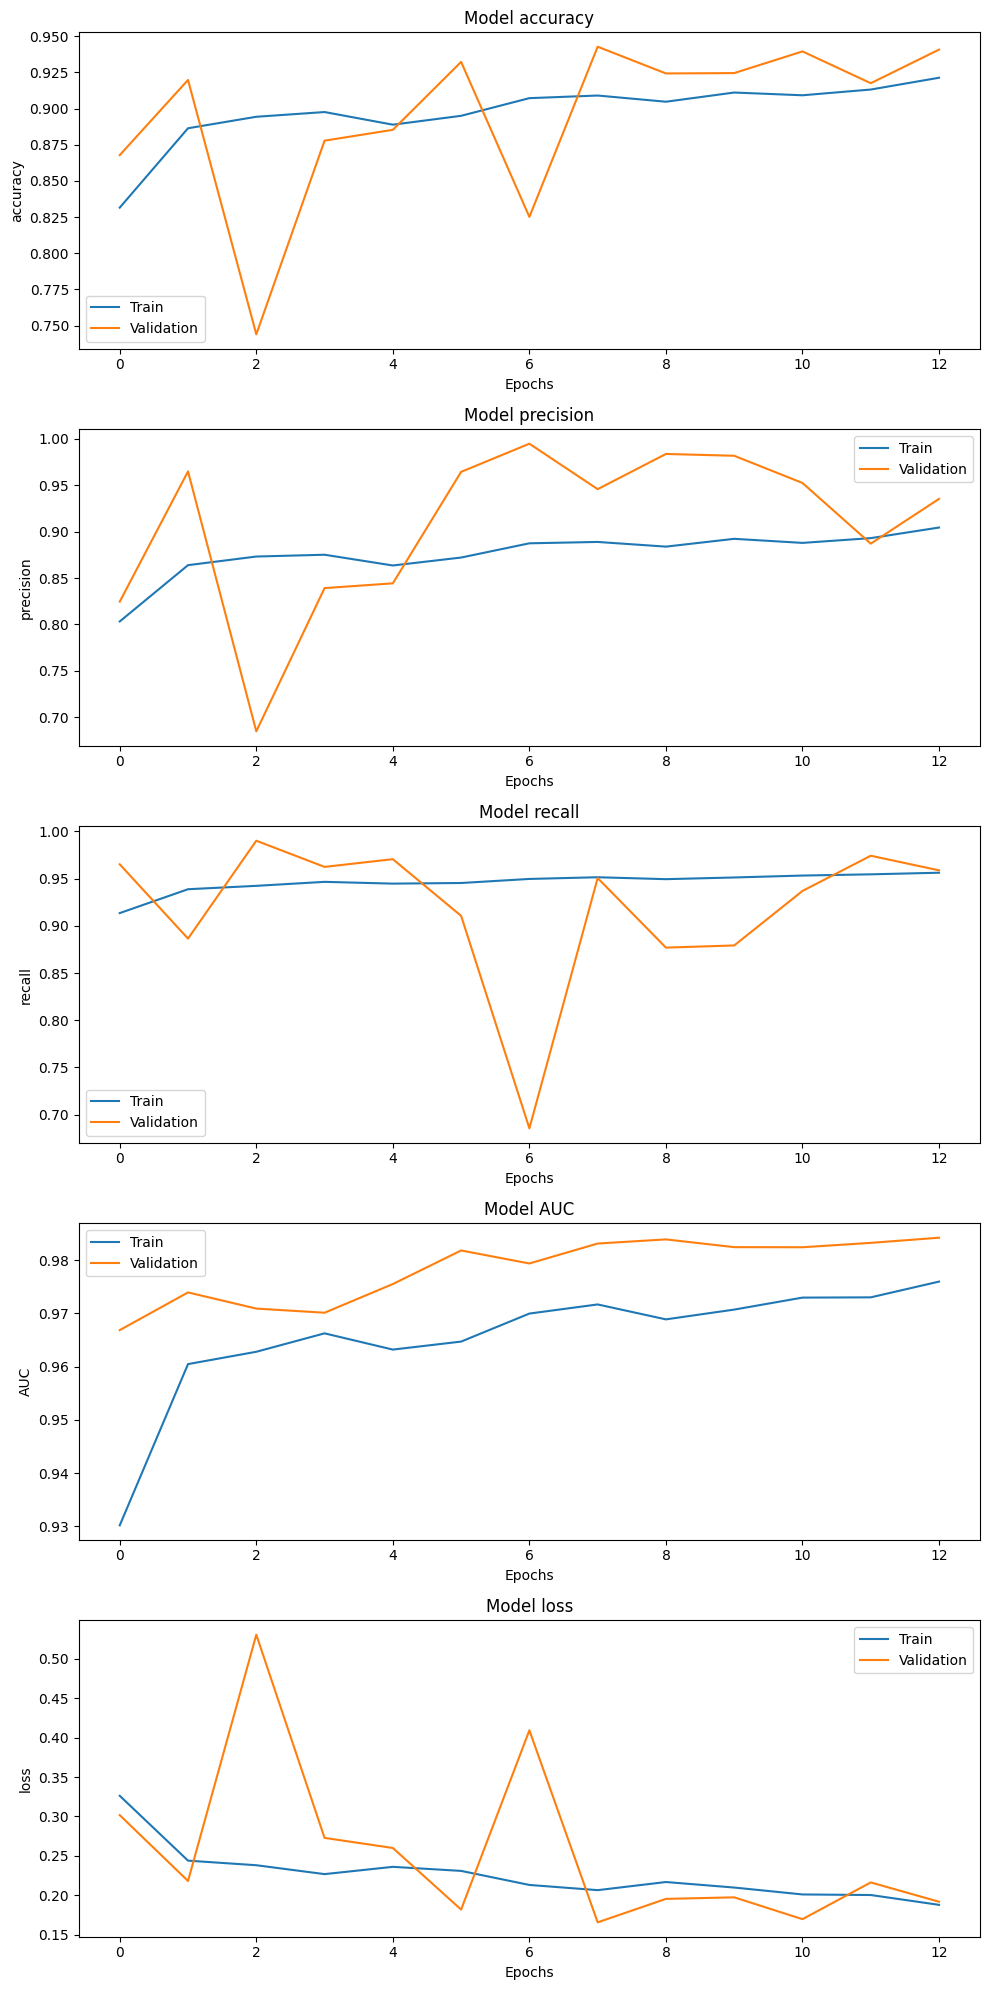

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Confusion Matrix:
[[1267  115]
 [  68 1550]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9491    0.9168    0.9326      1382
           1     0.9309    0.9580    0.9443      1618

    accuracy                         0.9390      3000
   macro avg     0.9400    0.9374    0.9385      3000
weighted avg     0.9393    0.9390    0.9389      3000



In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Evaluate the trained model on the test dataset and return results as a dictionary
results = model_fcnn.evaluate(test_X_rgb, test_Y, return_dict=True)

# Display evaluation metrics in a readable format
print("\nEvaluation Results:")
for metric, value in results.items():
    print(f"{metric:>20}: {value:.4f}")

# Plot training and validation metrics (assumes 'plot_score' is a custom function)
plot_score(history_fcnn)

# Predict probabilities on the test set
pred_probs = model_fcnn.predict(test_X_rgb)

# Convert predicted probabilities to binary class labels (threshold = 0.5)
pred_labels = (pred_probs > 0.5).astype("int32")

# Generate and print the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(test_Y, pred_labels))

# Print detailed classification report (precision, recall, F1, etc.)
print("\nClassification Report:")
print(classification_report(test_Y, pred_labels, digits=4))